In [ ]:
import re
import matplotlib.pyplot as plt
import json

In [ ]:
lines = []
with open("ver3/train.log", "rt") as f:
    lines = f.readlines()

In [75]:
pattern = re.compile(r"\[INFO\]: TRAIN epoch: ([\d]+) loss: ([\d\.]+), time: ([\d\.]+)s", re.DOTALL)

In [76]:
train = []
for line in lines:
    match = pattern.match(line.strip())
    if match:
        train.append((int(match.group(1)), float(match.group(2))))

In [77]:
pattern = re.compile(r"\[INFO\]: VALIDATION epoch: ([\d]+) loss: ([\d\.]+)", re.DOTALL)

In [78]:
validation = []
for line in lines:
    match = pattern.match(line.strip())
    if match:
        validation.append((int(match.group(1)), float(match.group(2))))

# Epochs

In [79]:
x = list(range(1, 101))
yt = [0] * 100
for e, l in train:
    yt[e] += l
yt = [m/35 for m in yt]

yv = [0] * 100
for e, l in validation:
    yv[e] += l
yv = [m/5 for m in yv]

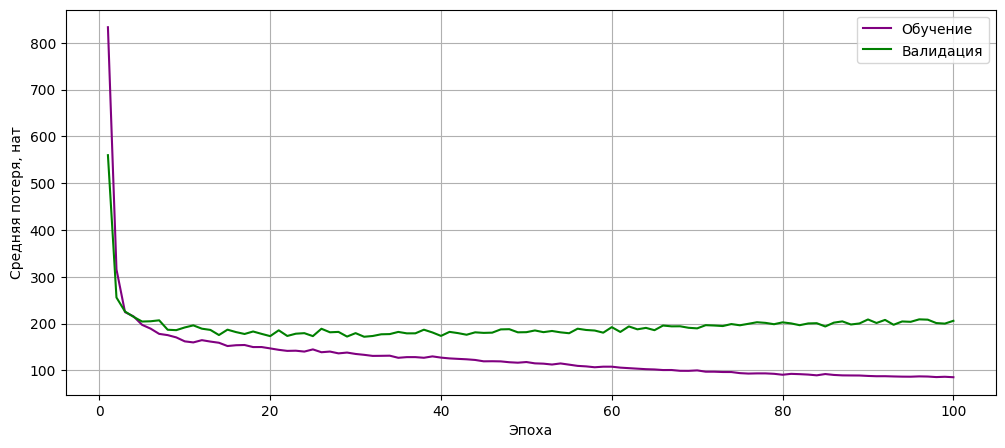

In [80]:
fig = plt.figure(figsize=(12, 5))

plt.plot(x, yt, label="Обучение", color="purple")
plt.plot(x, yv, label="Валидация", color="green")

plt.xlabel("Эпоха")
plt.ylabel("Средняя потеря, нат")

plt.legend()

plt.grid()
plt.show()

In [81]:
x = list(range(35*100))
yt = [t[1] for t in train]

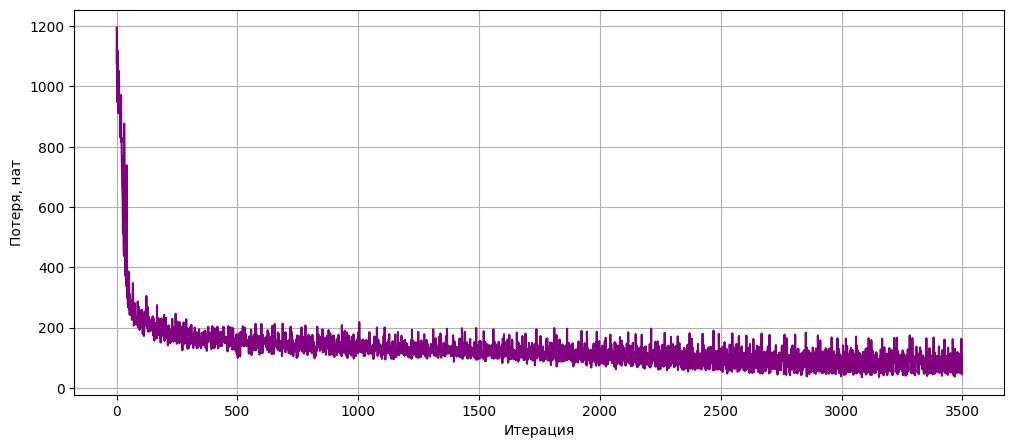

In [82]:
fig = plt.figure(figsize=(12, 5))

plt.plot(x, yt, color="purple")

plt.xlabel("Итерация")
plt.ylabel("Потеря, нат")

plt.grid()
plt.show()

In [83]:
x = list(range(5*100))
yv = [v[1] for v in validation]

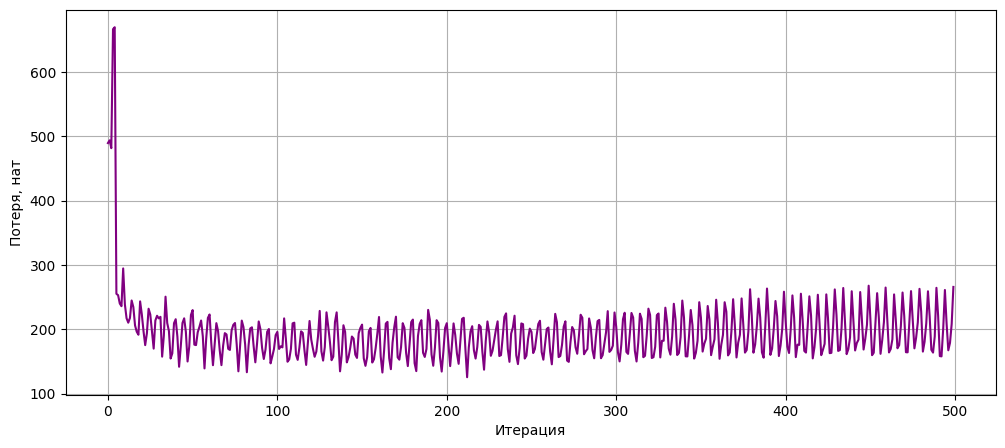

In [84]:
fig = plt.figure(figsize=(12, 5))

plt.plot(x, yv, color="purple")

plt.xlabel("Итерация")
plt.ylabel("Потеря, нат")

plt.grid()
plt.show()